# Global Cybercrime Regulation Analysis: 2020–2024
### An Exploratory Data Analysis of 194 Countries
**Tools:** Python, Pandas, Matplotlib, Seaborn, Plotly, Scikit-learn

###### CyberCrime EDA (Starting Expected Results)
- This is EDA for a cybercrime dataset which will hopefully help us learn something about the rise or fall in cybersecurity regulations in 194 different countries
- This can also help us see which of the countries have improved their cybercrime regulation over the course of 4 years and which of them have not improved or worsened.

In [1]:
# importing all of the necessary and important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

%matplotlib inline

In [2]:
# Loading the dataset
df = pd.read_csv("cybercrime_regulation_change_2020_2024.csv")
df.head()

,country_code,country_name,score_2020,score_2024,score_change,percent_change,region,income_level
0,AFG,Afghanistan,0.000000,0.104714,0.104714,inf,Asia,Low Income
1,ALB,Albania,0.932751,1.000000,0.067249,7.21,Europe,Upper Middle Income
2,DZA,Algeria,0.621538,0.922571,0.301033,48.43,Africa,Upper Middle Income
3,AND,Andorra,0.348979,0.815143,0.466164,133.58,Other,Not Classified
4,AGO,Angola,0.347746,0.702000,0.354254,101.87,Africa,Lower Middle Income


In [3]:
# Looking at basic informations of the dataset like column names, data types, missing  values, and so on

df.shape

(194, 8)

In [4]:
df.columns

Index(['country_code', 'country_name', 'score_2020', 'score_2024',
       'score_change', 'percent_change', 'region', 'income_level'],
      dtype='object')

In [5]:
df.columns.tolist()

['country_code',
 'country_name',
 'score_2020',
 'score_2024',
 'score_change',
 'percent_change',
 'region',
 'income_level']

In [6]:
df.dtypes

country_code       object
country_name       object
score_2020        float64
score_2024        float64
score_change      float64
percent_change    float64
region             object
income_level       object
dtype: object

In [7]:
df.isnull().sum()

country_code      0
country_name      0
score_2020        0
score_2024        0
score_change      0
percent_change    4
region            0
income_level      0
dtype: int64

In [8]:
# As it can be seen, there is a few missing values in percent_change
df.describe() # this is the statistical summary 

,score_2020,score_2024,score_change,percent_change
count,194.000000,194.000000,194.000000,190.0000
mean,0.603831,0.741275,0.137444,inf
std,0.380604,0.293498,0.212881,NaN
min,0.000000,0.000000,-0.455238,-62.9800
25%,0.284291,0.552286,0.000000,0.0000
50%,0.646560,0.831071,0.067249,9.7350
75%,1.000000,1.000000,0.234541,95.6825
max,1.000000,1.000000,0.831714,inf


In [9]:
# droping the percent_change feature due to inf and NaN values from division by zero

df = df.drop(columns=["percent_change"])

# confirming
print("Columns now:", df.columns.tolist())
print("Any nulls?", df.isnull().sum().any())
print(f"\nKey Headline: Average cybercrime regulation score improved from {df['score_2020'].mean():.3f} to {df['score_2024'].mean():.3f}")
print(f"Countries that improved: {(df['score_change'] > 0).sum()} out of {len(df)}")
print(f"Countries that worsened: {(df['score_change'] < 0).sum()} out of {len(df)}")
print(f"Countries unchanged: {(df['score_change'] == 0).sum()} out of {len(df)}")

Columns now: ['country_code', 'country_name', 'score_2020', 'score_2024', 'score_change', 'region', 'income_level']
Any nulls? False

Key Headline: Average cybercrime regulation score improved from 0.604 to 0.741
Countries that improved: 112 out of 194
Countries that worsened: 21 out of 194
Countries unchanged: 61 out of 194


- So, 57.7% of the countries improved
- 31.4% of the countries stayed unchanged, which could mean that regulatory implementation are stagnant or maybe slow(ineffective)
- Only 10.8% of the countries worsened

In [10]:
# the statistical summary shows that there was an overall reduction in the crimerate for most of the countries

# Distribution of Categorical Columns

print("Regions:\\n", df["region"].value_counts())
print("\\nIncome Levels:\\n", df["income_level"].value_counts())

Regions:\n region
Africa           51
Europe           40
Asia             31
Other            19
North America    17
Middle East      14
Oceania          12
South America    10
Name: count, dtype: int64
\nIncome Levels:\n income_level
Upper Middle Income    52
High Income            48
Lower Middle Income    46
Low Income             29
Not Classified         19
Name: count, dtype: int64


## Global Overview 

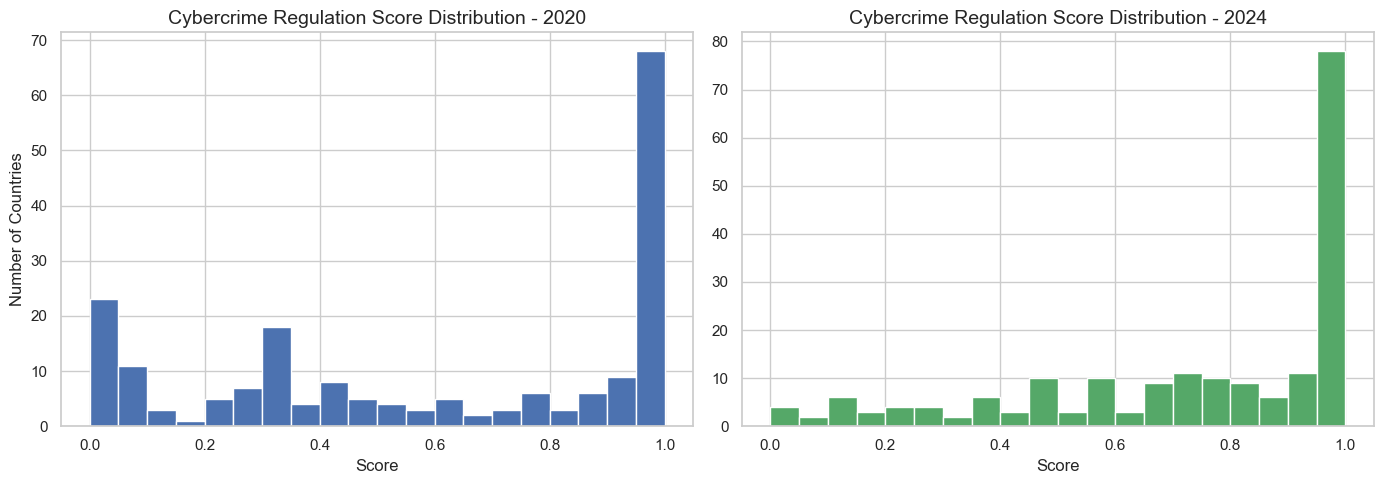

In [11]:
# Score Distribution 2020 vs 2024

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# for 2020
axes[0].hist(df["score_2020"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("Cybercrime Regulation Score Distribution - 2020", fontsize=14)
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Number of Countries")

# for 2024
axes[1].hist(df["score_2024"], bins=20,  color="#55A868", edgecolor="white")
axes[1].set_title("Cybercrime Regulation Score Distribution - 2024", fontsize=14)
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

- as it can be seen, the crime regulation score has improved overall from being around 67-68% in 2020 to around 79% in 2024.
- important thing to notice, in 2020, the regulation seems to be very poor and it could be because most of the world was working online through digital platforms and many people were discovering or acclimatizing with the digital environment, which furthermore might have fueled the rise in cybercrime

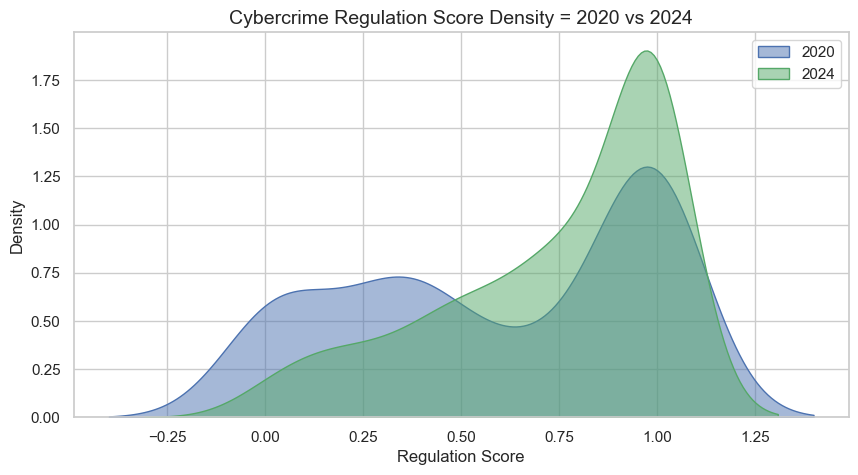

In [12]:
# KDE Overlay (2020 vs 2024 on same plot)

plt.figure(figsize=(10, 5))
sns.kdeplot(df["score_2020"], fill=True, color="#4C72B0", label="2020", alpha=0.5) 
sns.kdeplot(df["score_2024"], fill=True, color="#55A868", label="2024", alpha=0.5) 

plt.title("Cybercrime Regulation Score Density = 2020 vs 2024", fontsize=14)
plt.xlabel("Regulation Score")
plt.ylabel("Density")

plt.legend()
plt.savefig("score_kde.png", dpi=150, bbox_inches="tight")
plt.show()

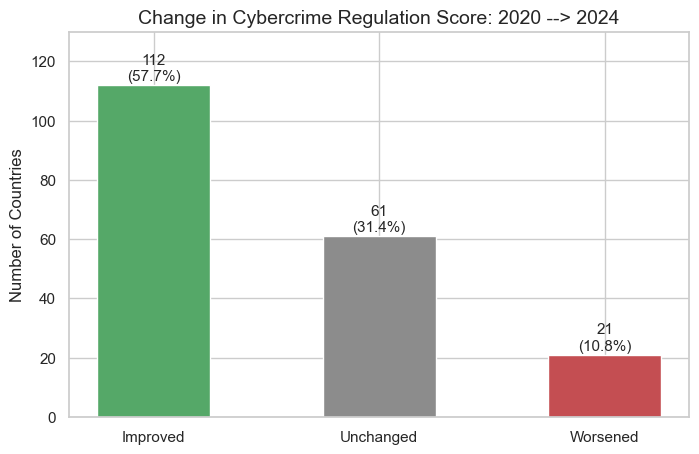

In [13]:
# Headline Summary Bar

labels = ["Improved", "Unchanged", "Worsened"]
values = [112, 61, 21]
colors = ["#55A868", "#8C8C8C", "#C44E52"]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, edgecolor="white", width=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f"{val}\n({val/194*100:.1f}%)", ha="center", fontsize=11)

plt.title("Change in Cybercrime Regulation Score: 2020 --> 2024", fontsize=14)
plt.ylabel("Number of Countries")
plt.ylim(0, 130)

plt.savefig("change_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Choropleth World Map

fig = px.choropleth(
    df,
    locations="country_code",
    color="score_2024",
    hover_name="country_name",
    hover_data={"score_2020": True, "score_2024": True, "score_change": True},
    color_continuous_scale="RdYlGn",
    title="Global Cybercrime Regualtion Score - 2024",
    labels={"score_2024": "Regulation Score"}
)

fig.update_layout(
    geo=dict(showframe= False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Score")
)

fig.write_html("world_map.html")
fig.show()

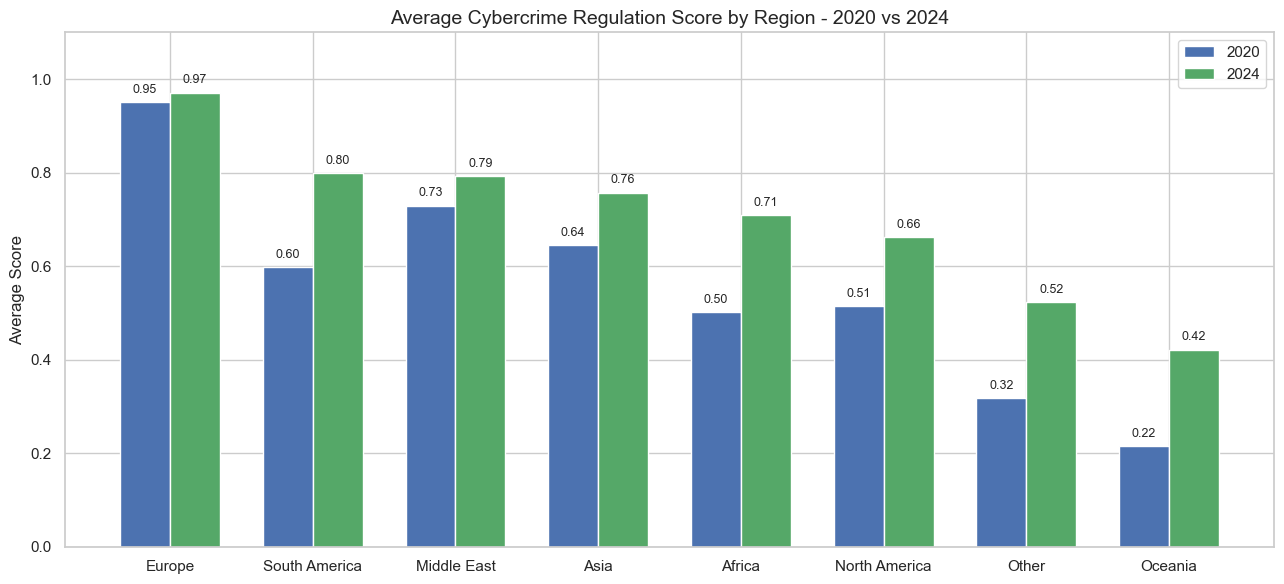

In [15]:
# Average Score by Region (2020 vs 2024)

# grouping the dataframe by region and calculating the mean of score_2020 and score_2024
# this should give us one average score per region for each year

region_avg = df.groupby("region")[["score_2020", "score_2024"]].mean().sort_values("score_2024", ascending=False)

# placing two bars side-by-side for each region (one for 2020, one for 2024)
# x holds the position index for each region on the x-axis

x = range(len(region_avg))
width = 0.35  # this is the width of each bar; keeping it less than 0.5 so that it won't overlap each other

fig, ax = plt.subplots(figsize=(13, 6))

# Plot 2020 bars slightly to the left of the center (just for visual validation)
# (i - width/2)

bars1 = ax.bar([i - width/2 for i in x], region_avg["score_2020"], width, label="2020", color="#4C72B0", edgecolor="white")

# Plot 2025 bars slightly to the right of center (i + width/2)

bars2 = ax.bar([i + width/2 for i in x], region_avg["score_2024"], width, label="2024", color="#55A868", edgecolor="white")

# setting the x-axis tick positions and label them with region names

ax.set_xticks(list(x))
ax.set_xticklabels(region_avg.index, fontsize=11)
ax.set_title("Average Cybercrime Regulation Score by Region - 2020 vs 2024", fontsize=14)
ax.set_ylabel("Average Score")
ax.set_ylim(0, 1.1)  # this is set slightly above 1.0 to give room for value labels
ax.legend()

# adding the actual score value on top of each bar for easy reading

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)
    
plt.tight_layout()
plt.savefig("region_avg.png", dpi=150, bbox_inches="tight")
plt.show()

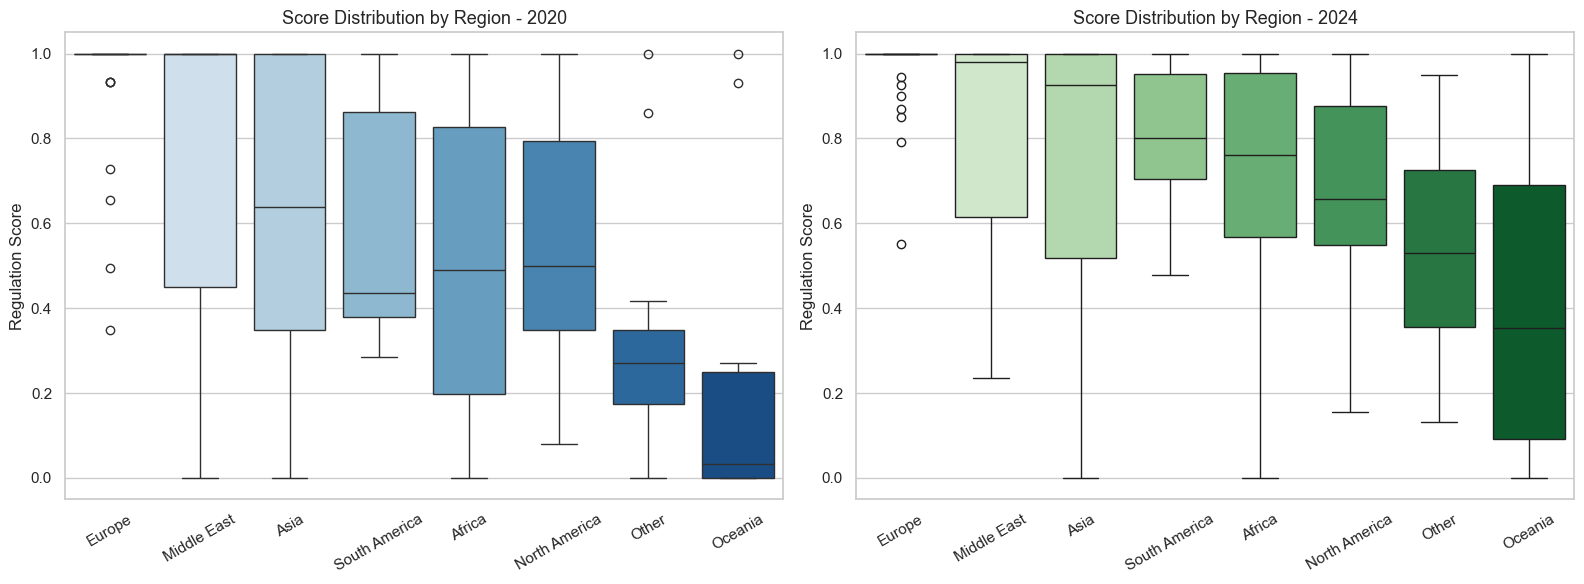

In [16]:
# Boxplot by Region

# Sort regions by their median 2024 score - highest median region appers first
# This makes the boxplots easier to compare visually

region_order = df.groupby("region")["score_2024"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A boxplot shows the spread of scores within each region:
'''
- The box covers the middle 50% of countries (25th to 75th percentile)
- The line inside the box is the median
- The whiskers extend to min/max (excluding outliers)
- Dots beyond whisers are outlier countries
'''

# Left plot: 2020 scores
sns.boxplot(data=df, x="region", y="score_2020", order=region_order,
            palette="Blues", ax=axes[0])
axes[0].set_title("Score Distribution by Region - 2020", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Regulation Score")
axes[0].tick_params(axis="x", rotation=30)   # rotating labels so they don't overlap

# Right plot: 2024 scores -- compare with 2020 to see if spread changed

sns.boxplot(data=df, x="region", y="score_2024", order=region_order, 
            palette="Greens", ax=axes[1])
axes[1].set_title("Score Distribution by Region - 2024", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("Regulation Score")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("region_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

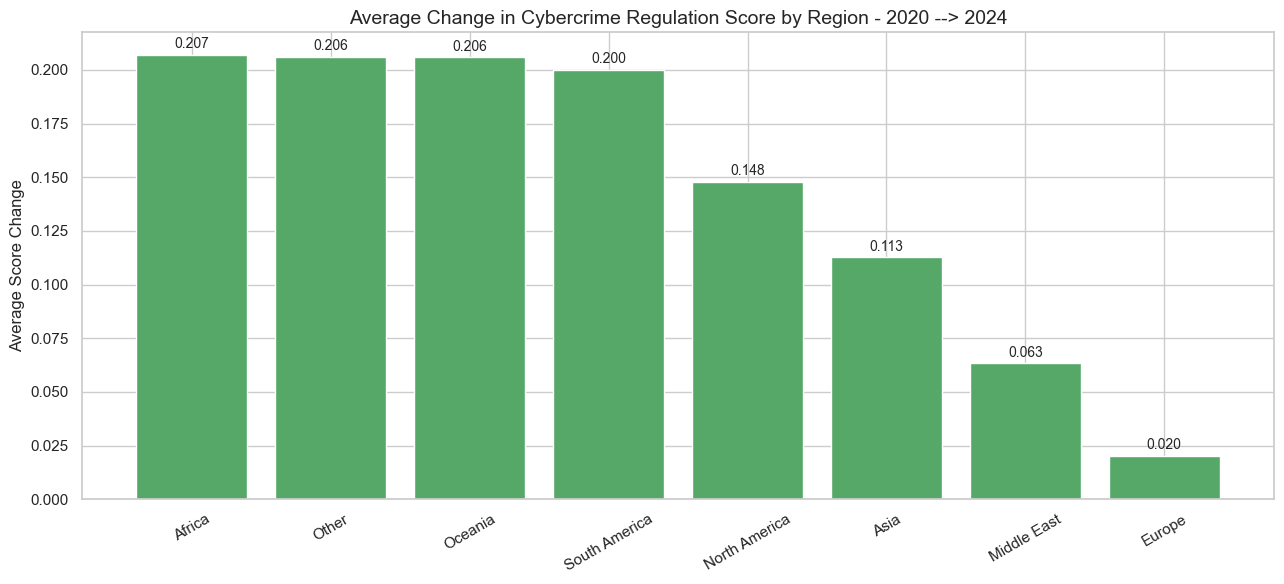

In [17]:
# Average Change by Region

# Calculate the mean score_change for each region
# This tells us which regions improved the most on average

region_change = df.groupby("region")["score_change"].mean().sort_values(ascending=False)

# Coloring bars green if the region improved on average and red if it declined

colors = ["#55A868" if v>=0 else "#C44E52" for v in region_change.values]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(region_change.index, region_change.values, color=colors, edgecolor="white")

# Adding value labels on top of each bar
# If the bar goes up (positive), label above the bar
# If the bar goes down (negative), label below the bar

for bar, val in zip(bars, region_change.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003 if val >= 0 else bar.get_height() - 0.012,
            f"{val:.3f}", ha="center", fontsize=10)

ax.set_title("Average Change in Cybercrime Regulation Score by Region - 2020 --> 2024", fontsize=14)
ax.set_ylabel("Average Score Change")

# Draw a horizontal line at 0 as a visual reference point
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("region_change.png", dpi=150, bbox_inches="tight")
plt.show()

--> Regions that started lowest improved the most, suggesting a global "catch-up" trend in cybercrime regulation -- however Middle East and Asia are notable execptions, improving far less than their starting scores would suggest

## additional regional observations

- The boxplot comparison reveals that Europe's within-region consistency improved significantly -- countries converged towards high scores by 2024.

- Middle East and Asia show high within-region inequality in both years, suggesting uneven regulatory development within these regions.

- The change chart reveals a "catch-up" pattern -- the lowest-scoring regions (Africa, Oceania) showed the greatest improvement.

- Middle East and Asia are notable exceptions to this trend, underperforming relative to their potential for improvement.

In [18]:
# Now we are grouping top countries and bottom countries per region
# Top 3 & Bottom 3 Countries per Region

# We want to find the 3 highest and 3 lowest scoring countries in each region
# This helps identify leaders and laggards with every region

top_bottom = []  # this is an empty list to collect results from each region

for region in df['region'].unique():
    # Filtering the dataframe to only rows belonging to this region
    region_df = df[df["region"] == region].copy()

    # Get the 3 countries with the highest score_2024 in this region
    top3 = region_df.nlargest(3, "score_2024")[["country_name", "region", "score_2024", "score_change"]]
    top3["rank_type"] = "Top 3"

    # Get the 3 countries with the lowest score_2024 in the same region
    bottom3 = region_df.nsmallest(3, "score_2024")[["country_name", "region", "score_2024", "score_change"]]
    bottom3["rank_type"] = "Bottom 3"

    # Combining top and bootm for this region and adding to our list
    top_bottom.append(pd.concat([top3, bottom3]))

# Combining results from all regions into one dataframe
top_bottom_df = pd.concat(top_bottom).reset_index(drop=True)

# Printing out the results region by region in a clean readable format
for region in df["region"].unique():
    print(f"\n{'='*50}")
    print(f"  {region}")
    print(f"{'='*50}")
    subset = top_bottom_df[top_bottom_df["region"] == region]
    print(subset[["rank_type", "country_name", "score_2024", "score_change"]].to_string(index=False))


  Asia
rank_type              country_name  score_2024  score_change
    Top 3                Azerbaijan    1.000000      0.000000
    Top 3                     China    1.000000      0.000000
    Top 3                   Georgia    1.000000      0.067249
 Bottom 3 Korea, Dem. People's Rep.    0.000000      0.000000
 Bottom 3               Afghanistan    0.104714      0.104714
 Bottom 3               Timor-Leste    0.143429      0.143429

  Europe
rank_type           country_name  score_2024  score_change
    Top 3                Albania    1.000000      0.067249
    Top 3                Belgium    1.000000      0.000000
    Top 3               Bulgaria    1.000000      0.000000
 Bottom 3 Bosnia and Herzegovina    0.552286      0.203307
 Bottom 3              Lithuania    0.791714     -0.208286
 Bottom 3                Austria    0.851000     -0.149000

  Africa
rank_type     country_name  score_2024  score_change
    Top 3            Benin    1.000000      0.238932
    Top 3 Egypt, Ar

## Key Country_Level 

- **North Korea** stands out as a critical anamoly - a score of 0.0 in both 2020 and 2024 indicates a complete absence of cybercrime regulation. Even though, it is widely recognized as a state-sponsored cyber threat actor on a global level.

- **Europe's regulatory floor is remarkably high** -- even the lowest-scoring European countries like Bosnia: 0.55, Lithunia: 0.79, Austria: 0.85 outperform most other regions' averages.

- **Lithuania (-0.208) and Austria (-0.149)** are notable anamolies because they are high-income European countries whose regulatory scores declined between 2020 and 2024 which invites further investigation.

- **Conflict-affected states** like Yemen, Iraq, West Bank and Gaza consistently appear at the bottom of the Middle East rankings suggesting that political instability is a signifant factor that affects cybercrime regulatory development.

## Standout Country-Level Findings (for all regions)

- **Kiribati (+0.766) and Gabon (+0.730)** recorded the two largest regulatory improvements in the entire dataset -- both developing nations, suggesting that rapid reform is achievable regardless of economic size.

- **Regulatory black holes** -- North Korea, Eritrea, Guinea-Bissau, and Micronesia all scored 0.0 in both the years, representing countries with a compelete absence of cybercrime regulation across the entire study period.

- **Small nations show surprising agility** -- Liechtenstein (+0.533), Seychelees (+0.575), and Kiribati (+0.766) all achieved dramatic improvements, possibly due to simpler governanvce structures enabling faster policy reforms. (because there are less people living there which makes it relatively easy to implement the regulations in the nation)

- **Cuba scoring 1.0** highlights an important dataset limitation -- the score reflects the existence of regulatory frameworks, not their democratic quality or enforcement effectiveness.

- **Wealthy nation declines** -- Monaco, Austria, and Lithuania all recorded negative score changes, challenging the assumption that high-income countries consistently maintain or improve their regulatory standing.

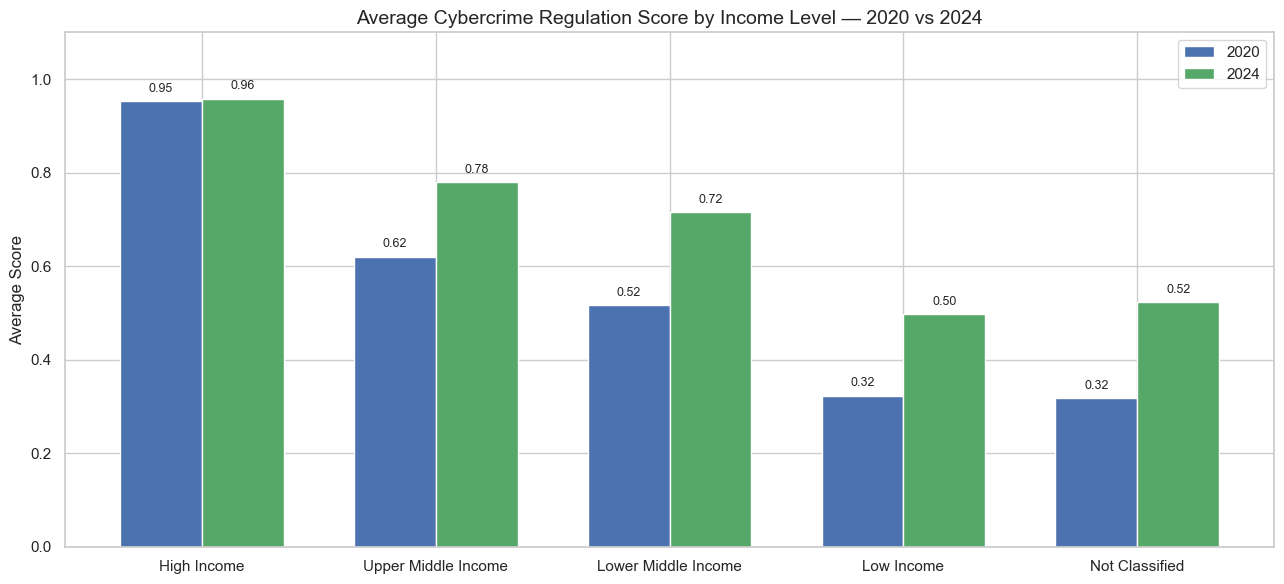

In [19]:
# income level analysis

# average score by income level (2020 vs 2024)

# Define a logical order for income levels from highest to lowest
# This makes the chart easier to read and interpret
income_order = ["High Income", "Upper Middle Income", "Lower Middle Income", "Low Income", "Not Classified"]

# Calculate mean scores for each income group in both years
income_avg = df.groupby("income_level")[["score_2020", "score_2024"]].mean().reindex(income_order)

x = range(len(income_avg))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

# Plot 2020 bars to the left and 2024 bars to the right for each income group
bars1 = ax.bar([i - width/2 for i in x], income_avg["score_2020"], width, label="2020", color="#4C72B0", edgecolor="white")
bars2 = ax.bar([i + width/2 for i in x], income_avg["score_2024"], width, label="2024", color="#55A868", edgecolor="white")

ax.set_xticks(list(x))
ax.set_xticklabels(income_avg.index, fontsize=11)
ax.set_title("Average Cybercrime Regulation Score by Income Level — 2020 vs 2024", fontsize=14)
ax.set_ylabel("Average Score")
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("income_avg.png", dpi=150, bbox_inches="tight")
plt.show()

### Is the Gap Between Rich and Poor Closing or Widening?

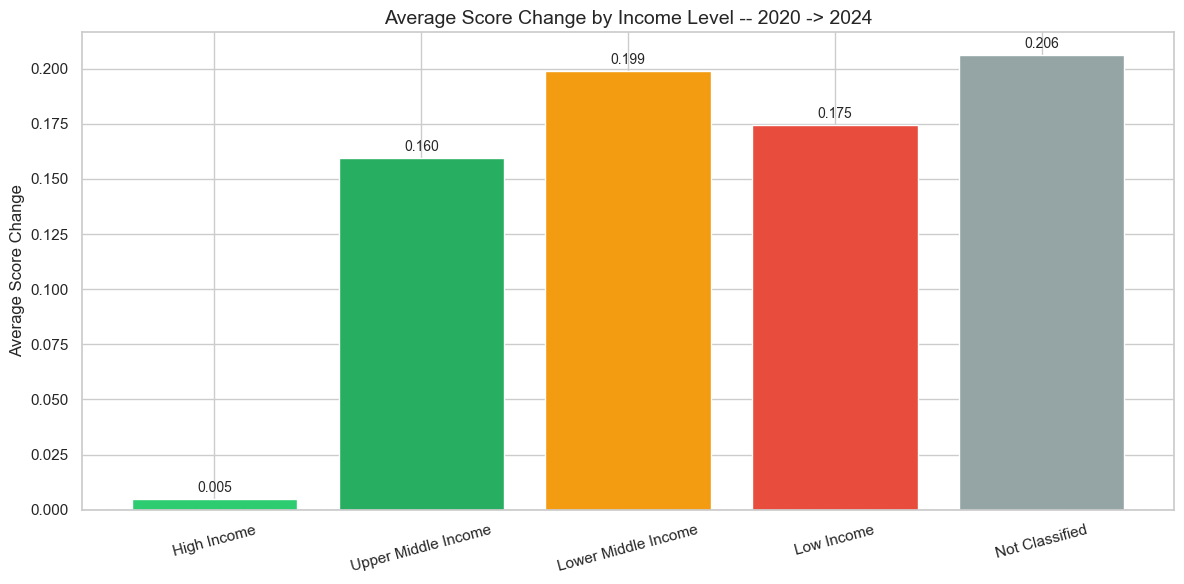

In [20]:
# Calculate the average score change per income group
# This is the KEY research question -- are poorer countries catching up?
income_change = df.groupby("income_level")["score_change"].mean().reindex(income_order)

# coloring bars by income group for visual distinction
colors = ["#2ecc71", "#27ae60", "#f39c12", "#e74c3c", "#95a5a6"]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(income_change.index, income_change.values, color=colors, edgecolor="white")

# adding value labels on each bar
for bar, val in zip(bars, income_change.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003 if val >= 0 else bar.get_height() - 0.012,
            f"{val:.3f}", ha="center", fontsize=10)
    
ax.set_title("Average Score Change by Income Level -- 2020 -> 2024", fontsize=14)
ax.set_ylabel("Average Score Change")

# Reference line at zero
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("income_change.png", dpi=150, bbox_inches="tight")
plt.show()

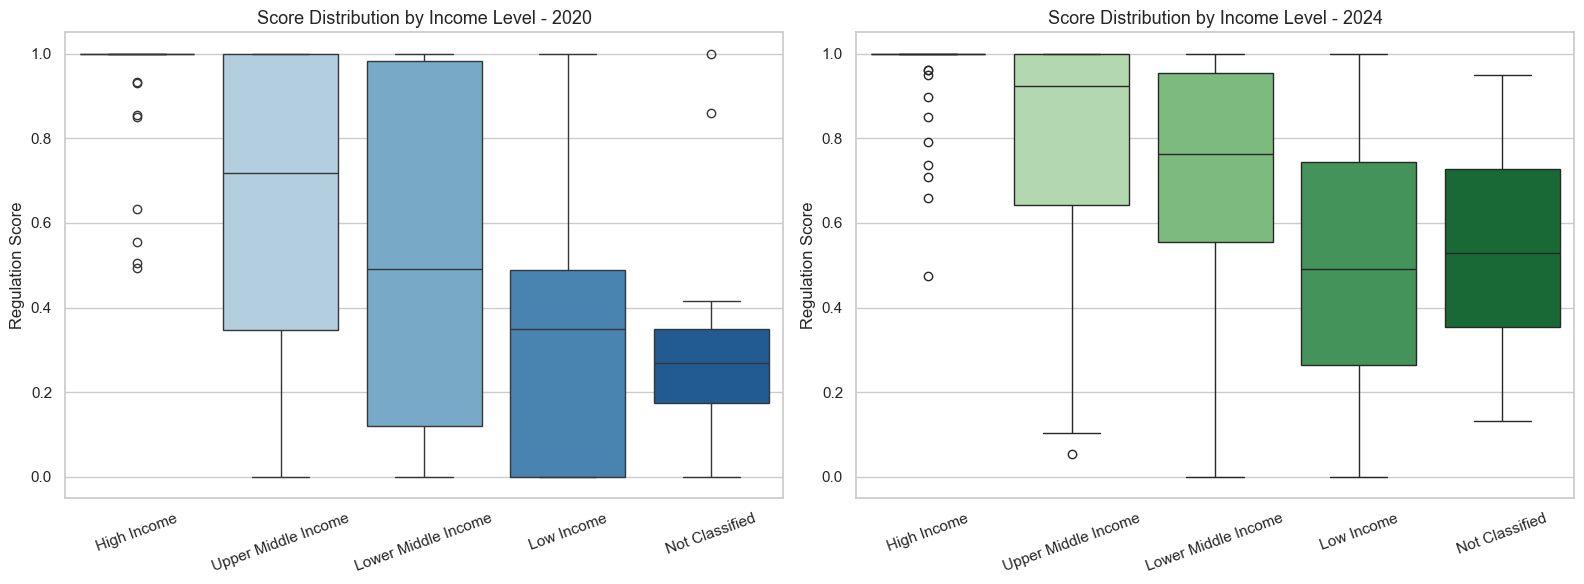

In [21]:
# Boxplot of Scores by Income Level

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot for 2020 -- shows how spread out scores are within each income group
sns.boxplot(data=df, x="income_level", y="score_2020", order=income_order,
            palette="Blues", ax=axes[0])
axes[0].set_title("Score Distribution by Income Level - 2020", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Regulation Score")
axes[0].tick_params(axis="x", rotation=20)

# Boxplot for 2024 -- compare with 2020 to see if inquality within groups changed
sns.boxplot(data=df, x="income_level", y="score_2024", order=income_order,
            palette="Greens", ax=axes[1])
axes[1].set_title("Score Distribution by Income Level - 2024", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("Regulation Score")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("income_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Scatter Plot: Income Group vs Score Change

# We can't directly plot income level on a numeric axis since it's categorical
# So we map each income level to a number to allow scatter plotting
# Higher number = higher income

income_map = {
    "Low Income": 1,
    "Lower Middle Income": 2,
    "Upper Middle Income": 3,
    "High Income": 4,
    "Not Classified": 0
}

# Create a new numeric column based on the mapping
df["income_numeric"] = df["income_level"].map(income_map)

# Color each dot by region so we can see geographic patterns too
fig = px.scatter(
    df,
    x="income_numeric",
    y="score_change",
    color="region",
    hover_name="country_name",
    hover_data={"score_2020": True, "score_2024": True, "income_level": True},
    title="Income Level vs Score Change -- 2020 -> 2024",
    labels={"income_numeric": "Income Level", "score_change": "Score Change"}
)

# Replace numeric axis labels with actual income income level names
fig.update_layout(
    xaxis=dict(
        tickvals=[0, 1, 2, 3, 4],
        ticktext=["Not Classified", "Low Income", "Lower Middle", "Upper Middle", "High Income"]
    )
)

fig.write_html("income_scatter.html")
fig.show()

In [23]:
# Top Overperformers & Underperformers

# Overperformers = Low or Lower Middle income countries with HIGH 2024 scores
# These are countries punching above their economic weight in regulation
overperformers = df[
    (df["income_level"].isin(["Low Income", "Lower Middle Income"])) &
    (df["score_2024"] >= 0.8)
][["country_name", "income_level", "region", "score_2024", "score_change"]].sort_values("score_2024", ascending=False)

# Underperformers = High income countries with LOW 2024 scores or negative change
# These are wealthy countries that should be doing better
underperformers = df[
    (df["income_level"] == "High Income") &
    (df["score_2024"] <= 0.5)
][["country_name", "income_level", "region", "score_2024", "score_change"]].sort_values("score_2024", ascending=False)

print("OVERPERFORMERS - Low/Lower Middle Income with Score >= 0.8")
print(overperformers.to_string(index=False))

print("\nUNDERPERFORMERS - High Income with Score <= 0.5")
print(underperformers.to_string(index=False))


OVERPERFORMERS - Low/Lower Middle Income with Score >= 0.8
    country_name        income_level region  score_2024  score_change
           Benin Lower Middle Income Africa    1.000000      0.238932
           Ghana Lower Middle Income Africa    1.000000      0.000000
Egypt, Arab Rep. Lower Middle Income Africa    1.000000      0.000000
            Togo          Low Income Africa    1.000000      0.074725
          Zambia Lower Middle Income Africa    1.000000      0.000000
     Philippines Lower Middle Income   Asia    1.000000      0.000000
        Pakistan Lower Middle Income   Asia    1.000000      0.372698
         Morocco Lower Middle Income Africa    1.000000      0.000000
           India Lower Middle Income   Asia    1.000000      0.000000
        Viet Nam Lower Middle Income   Asia    1.000000      0.000000
          Rwanda          Low Income Africa    1.000000      0.000000
        Tanzania Lower Middle Income Africa    1.000000      0.134999
      Uzbekistan Lower Middle I

## Key Income Level Findings

### Does higher income mean better regulation?
Yes — a clear positive correlation exists between income level and cybercrime 
regulation scores. High Income countries averaged 0.96 in 2024, while Low Income 
countries averaged 0.50.

### Is the gap closing or widening?
**The gap is closing.** The rate of improvement is inversely related to income level:
- High Income countries improved by only +0.005 on average — already near the ceiling
- Lower Middle Income countries improved by +0.199
- Low Income countries improved by +0.175

This "catch-up" pattern suggests that global cybercrime regulation is becoming 
more equitable over time, though a significant absolute gap still remains.

### Overperformers — Punching Above Their Weight
African nations dominate the overperformer list. Rwanda, Togo, Ghana, Ethiopia, 
Cabo Verde, and Eswatini all achieved scores of 0.80 or higher despite being 
classified as Low or Lower Middle Income. This challenges the assumption that 
strong cybercrime regulation requires significant economic resources.

### Within-Group Inequality
High Income countries showed reduced internal inequality by 2024 — scores 
converged toward the top. Low Income countries still show high internal 
inequality, meaning regulatory development within this group remains uneven.

### Notable Limitation
The Bahamas is the only High Income country scoring below 0.5, suggesting 
the underperformer threshold may need adjustment for a more nuanced analysis.

In [24]:
# Preparing data for clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

''' Lets cluster countries based on 3 features:
    score_2020, score_2024,  and score_change
    -this should group the countries by where they started in the begining, where they ended,
    and how much they did or did not improve
'''

# selecting only numeric columns we need for clustering
cluster_features = df[["score_2020", "score_2024", "score_change"]].copy()

# Standardize the features -- KMeans is distance-based, so all features need to be on the same scale
# StandardScaler converts each column to mean=0, std=1
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

print("Data ready for clustering.")
print(f"Shape: {cluster_scaled.shape}")

Data ready for clustering.
Shape: (194, 3)


##### using elbow method to find the optimal number of clusters

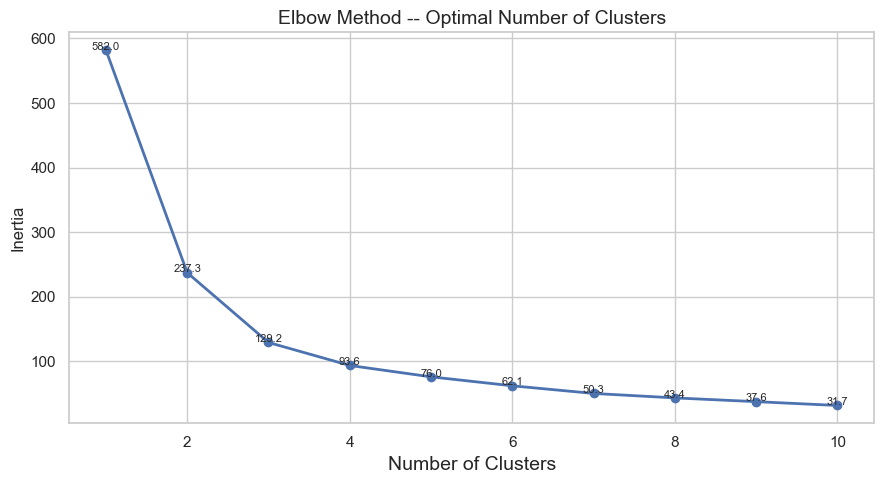

In [25]:
# The elbow method helps us decide how many cluters (k) to use
# We run KMeans for k=1 to k=10 and plot the inertia (within-cluter variance)
# The "elbow" point -- where improvement slows down -- is the best k

inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=555, n_init=10)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker="o", color="#4C72B0", linewidth=2)
plt.title("Elbow Method -- Optimal Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters", fontsize=14)
plt.ylabel("Inertia")

# adding value labels on each point
for k, val in zip(k_range, inertia):
    plt.text(k, val + 0.5, f"{val:.1f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("elbow.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# Now, applying KMeans and Label Clusters

# Based on the elbow plot, k=4 is typically the sweet spot for this kind of data
# If your elbow plot shows a different clear elbow, change n_clusters accordingly

k = 4
km = KMeans(n_clusters=k, random_state=555, n_init=10)
df["cluster"] = km.fit_predict(cluster_scaled)

# look at the average values per cluster to understand what each cluster represents
cluster_summary = df.groupby("cluster")[["score_2020", "score_2024", "score_change"]].mean()

print("CLuster Summary:")
print(cluster_summary)

CLuster Summary:
         score_2020  score_2024  score_change
cluster                                      
0          0.956051    0.959395      0.003345
1          0.439479    0.689583      0.250105
2          0.174592    0.773526      0.598934
3          0.162346    0.263958      0.101612


In [27]:
# Labeling Clusters with Meaningful Names

# After seeing the cluster summary, we assign meaningful labels
# The labels below are based on typical patterns -- adjust them if your cluster summary shows different characteristics

# Map cluster numbers to descriptive labels based on the summary output
# We may need to adjust the mapping after seeing the cluster summary
cluster_labels = {
    0: "Consisten Leaders",     # low scores, little change
    1: "Moderate Developers",          # high scores in both years
    2: "Reapid Improvers",            # low/mid start, big improvement
    3: "Stagnant Low Regulators"          # mid scores, moderate improvement  
}

df["cluster_label"] = df["cluster"].map(cluster_labels)

# Count how many countries fall into each other
print("Countries per Cluster:")
print(df["cluster_label"].value_counts())

Countries per Cluster:
cluster_label
Consisten Leaders          95
Stagnant Low Regulators    41
Moderate Developers        36
Reapid Improvers           22
Name: count, dtype: int64


In [28]:
# Visualize CLusters

# Scatter plot of score_2020 vs score_2024 colored by cluster
# Each dot is a country - the diagonal line would represent "no change"
# Dots above the diagonal improved, dots below worsened

fig = px.scatter(
    df, x="score_2020",
    y="score_2024",
    color="cluster_label",
    hover_name="country_name",
    hover_data={"score_change": True, "region": True, "income_level": True},
    title="Country Clusters - Cybercrime Regulation Score 2020 vs 2024",
    labels={"score_2020": "Score 2020", "score_2024": "Score 2024"},
    color_discrete_sequence=px.colors.qualitative.Set2
)

# Adding a diagonal reference line - countries ON this line didn't change at all
fig.add_shape(
    type="line", x0=0, y0=0, x1=1, y1=1,
    line=dict(color="gray", dash="dash", width=1)
)

fig.update_traces(marker=dict(size=7, opacity=0.8))
fig.write_html("clusters.html")
fig.show()

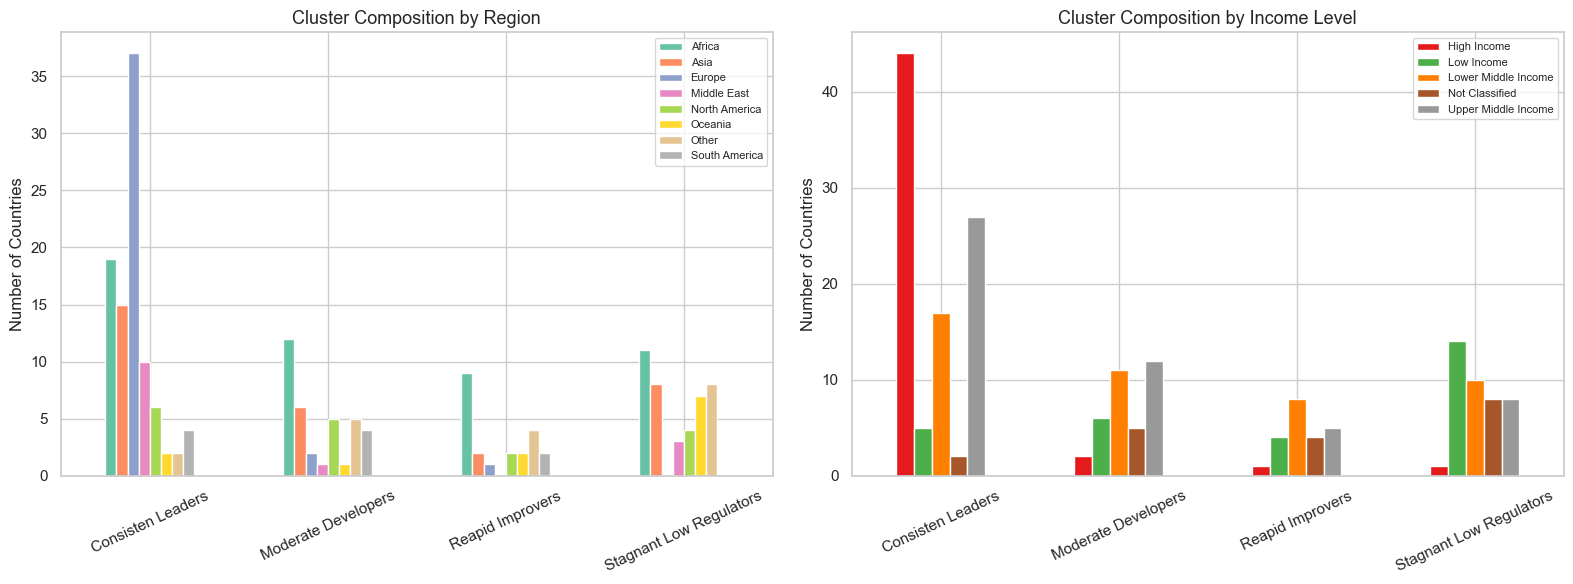

In [29]:
# Cluster Composition by Region and Income

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left chart: which regions dominate each cluster?
cluster_region = df.groupby(["cluster_label", "region"]).size().unstack(fill_value=0)
cluster_region.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_title("Cluster Composition by Region", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Countries")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(loc="upper right", fontsize=8)

# Right chart: which income levels dominate each cluster?
cluster_income = df.groupby(["cluster_label", "income_level"]).size().unstack(fill_value=0)
cluster_income.plot(kind="bar", ax=axes[1], colormap="Set1", edgecolor="white")
axes[1].set_title("Cluster Composition by Income Level", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Countries")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("cluster_composition.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 5: Clustering Analysis

### Methodology
Countries were clustered using KMeans (k=4) based on three features: 
score_2020, score_2024, and score_change. Features were standardized 
before clustering since KMeans is distance-based and sensitive to scale. 
The optimal k=4 was confirmed using the Elbow Method.

### Cluster Profiles

| Cluster | Countries | Avg 2020 | Avg 2024 | Avg Change |
|---|---|---|---|---|
| Consistent Leaders | 36 | 0.956 | 0.959 | +0.003 |
| Moderate Developers | 41 | 0.439 | 0.690 | +0.250 |
| Rapid Improvers | 22 | 0.175 | 0.774 | +0.599 |
| Stagnant Low Regulators | 95 | 0.162 | 0.264 | +0.102 |

### Key Clustering Findings

**Consistent Leaders (36 countries)**
Predominantly High Income nations that maintained near-perfect scores across 
both years. These countries represent the global benchmark for cybercrime 
regulation and have little remaining room for improvement.

**Rapid Improvers (22 countries)**
The most remarkable cluster — starting from near-zero regulation in 2020, 
these countries achieved an average score of 0.774 by 2024, an improvement 
of +0.599. This group demonstrates that rapid regulatory transformation is 
achievable and warrants further investigation into what drove such dramatic change.

**Moderate Developers (41 countries)**
A mid-range group showing consistent, meaningful progress (+0.250). 
Predominantly Upper Middle Income nations across mixed regions. 
On a positive trajectory but not yet near the regulatory frontier.

**Stagnant Low Regulators (95 countries)**
The largest and most concerning cluster — nearly half of all countries in 
the dataset. These nations started low and remain low, with an average 2024 
score of just 0.264. Dominated by African nations and Low Income countries, 
this cluster represents the most significant global cybersecurity vulnerability 
from a regulatory standpoint. The concentration of 95 countries in this group 
suggests systemic, structural barriers to regulatory development that go beyond 
individual national policy.

# Conclusion: Global Cybercrime Regulation Analysis (2020–2024)

## Overview
This analysis examined cybercrime regulation scores across 194 UN-recognized 
countries between 2020 and 2024, exploring how regulatory frameworks have 
evolved across regions, income levels, and country clusters. The dataset 
measures the strength and completeness of national cybercrime legal frameworks 
on a scale of 0.0 (no regulation) to 1.0 (fully developed regulation).

---

## Summary of Key Findings

### 1. Global Improvement, But Uneven Progress
The global average cybercrime regulation score improved from 0.604 in 2020 
to 0.741 in 2024. While 57.7% of countries improved, 31.4% showed no change 
whatsoever — a figure that suggests widespread regulatory stagnation rather 
than slow progress. Only 10.8% of countries declined.

### 2. A "Catch-Up" Pattern Across Regions and Income Levels
The regions and income groups that started lowest improved the most:
- Africa (+0.207), Oceania (+0.206), and South America (+0.200) led regional 
  improvements despite starting from weaker baselines
- Lower Middle Income countries improved by +0.199 on average, while 
  High Income countries improved by just +0.005
- This convergence suggests a global catch-up trend, though a significant 
  absolute gap remains between wealthy and developing nations

### 3. Europe Leads, But With Notable Anomalies
Europe maintained the highest regional average (0.97 in 2024), and its 
within-region consistency improved significantly. However, Lithuania (-0.208) 
and Austria (-0.149) — both high-income European nations — recorded score 
declines, challenging the assumption that wealthy nations consistently 
maintain regulatory standards.

### 4. Regulatory Black Holes Remain a Critical Concern
North Korea, Eritrea, Guinea-Bissau, and Micronesia all scored 0.0 in both 
2020 and 2024 — a complete absence of cybercrime regulation across the entire 
study period. From a cybersecurity perspective, North Korea is particularly 
significant given its well-documented history of state-sponsored cyber 
operations, making its zero regulatory score a notable geopolitical anomaly.

### 5. African Nations Overperform Relative to Income
Rwanda, Togo, Ghana, Ethiopia, Cabo Verde, and Eswatini all achieved scores 
above 0.80 despite being classified as Low or Lower Middle Income. This 
challenges the assumption that strong cybercrime regulation requires 
significant economic resources and suggests that political will and 
institutional focus can compensate for economic constraints.

### 6. Clustering Reveals Structural Divide
KMeans clustering (k=4) revealed that 95 out of 194 countries — nearly half 
the world — fall into the "Stagnant Low Regulators" cluster, with an average 
2024 score of just 0.264. This is the most significant finding of the analysis: 
the majority of nations remain deeply underprepared from a cybercrime regulatory 
standpoint, representing a systemic global vulnerability.

---

## Cybersecurity Implications
Cybercrime regulation scores are not merely administrative metrics — they 
directly reflect a nation's legal preparedness to investigate, prosecute, 
and deter cyber threats. Countries with low or stagnant scores represent 
weak links in global cybersecurity infrastructure. They may serve as 
operational bases for cybercriminal networks, lack extradition frameworks 
for cybercrime, and be unable to participate meaningfully in international 
cyber incident response.

The concentration of regulatory gaps in specific regions and income groups 
suggests that targeted international assistance, capacity building, and 
policy transfer programs could have outsized impact on global cyber resilience.

---

## Limitations
- Scores reflect the **existence** of regulatory frameworks, not their 
  enforcement effectiveness or quality
- The "Not Classified" income group (19 countries) limits income-level analysis
- The dataset does not capture actual cybercrime rates, meaning a high 
  score does not guarantee low cybercrime incidence
- Cross-country comparisons may be affected by differences in how 
  regulatory frameworks are defined and measured

---

## Future Research Directions
- Correlating regulation scores with actual cybercrime incident data 
  to test whether stronger frameworks reduce cyber threats
- Investigating what drove the dramatic improvements in Rapid Improver 
  nations such as Kiribati (+0.766) and Gabon (+0.730)
- Examining whether regulatory declines in wealthy nations (Austria, 
  Lithuania, Monaco) reflect deliberate policy changes or measurement gaps
- Longitudinal analysis beyond 2024 to track whether the catch-up 
  trend continues or plateaus